In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl


In [3]:
import joblib

X_train, X_test, y_train, y_test = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl"
)

le = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl"
)

print(X_train.shape)
print(X_test.shape)

(5055991, 77)
(1263998, 77)


# Random Forest

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [5]:
y_pred = rf.predict(X_test)

In [6]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("AUC:", auc)

AUC: 0.9812026915206983


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
mcc = matthews_corrcoef(y_test, y_pred)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

auc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")
print(f"AUC      : {auc:.4f}")

Accuracy : 0.9746
Precision: 0.9672
Recall   : 0.9746
F1-score : 0.9707
MCC      : 0.9295
AUC      : 0.9812


In [8]:
label_names = {
    0: "Benign",
    1: "Bot",
    2: "Brute Force -Web",
    3: "Brute Force -XSS",
    4: "DDOS attack-HOIC",
    5: "DDoS attack-LOIC-UDP",
    6: "DDoS attacks-LOIC-HTTP",
    7: "DoS attacks-GoldenEye",
    8: "DoS attacks-Hulk",
    9: "DoS attacks-SlowHTTPTest",
    10: "DoS attacks-Slowloris",
    11: "FTP-BruteForce",
    12: "Infiltration",
    13: "SQL Injection",
    14: "SSH-Bruteforce"
}

In [9]:
from sklearn.metrics import classification_report

target_names = [label_names[i] for i in range(15)]

print(classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=target_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.98      0.99      0.98    998829
                     Bot       1.00      1.00      1.00     28907
        Brute Force -Web       0.81      0.54      0.65       111
        Brute Force -XSS       0.78      0.64      0.71        45
        DDOS attack-HOIC       1.00      1.00      1.00     39772
    DDoS attack-LOIC-UDP       0.90      0.94      0.92       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115073
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     29040
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        11
   DoS attacks-Slowloris       0.99      0.99      0.99      1982
          FTP-BruteForce       0.08      0.10      0.09        10
            Infiltration       0.13      0.07      0.09     22764
           SQL Injection       0.85      0.65      0.73        17
         

In [10]:
attack_names = [
    "Benign",
    "Bot",
    "Brute Force-Web",
    "Brute Force-XSS",
    "DDOS-HOIC",
    "LOIC-UDP",
    "LOIC-HTTP",
    "GoldenEye",
    "Hulk",
    "SlowHTTPTest",
    "Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

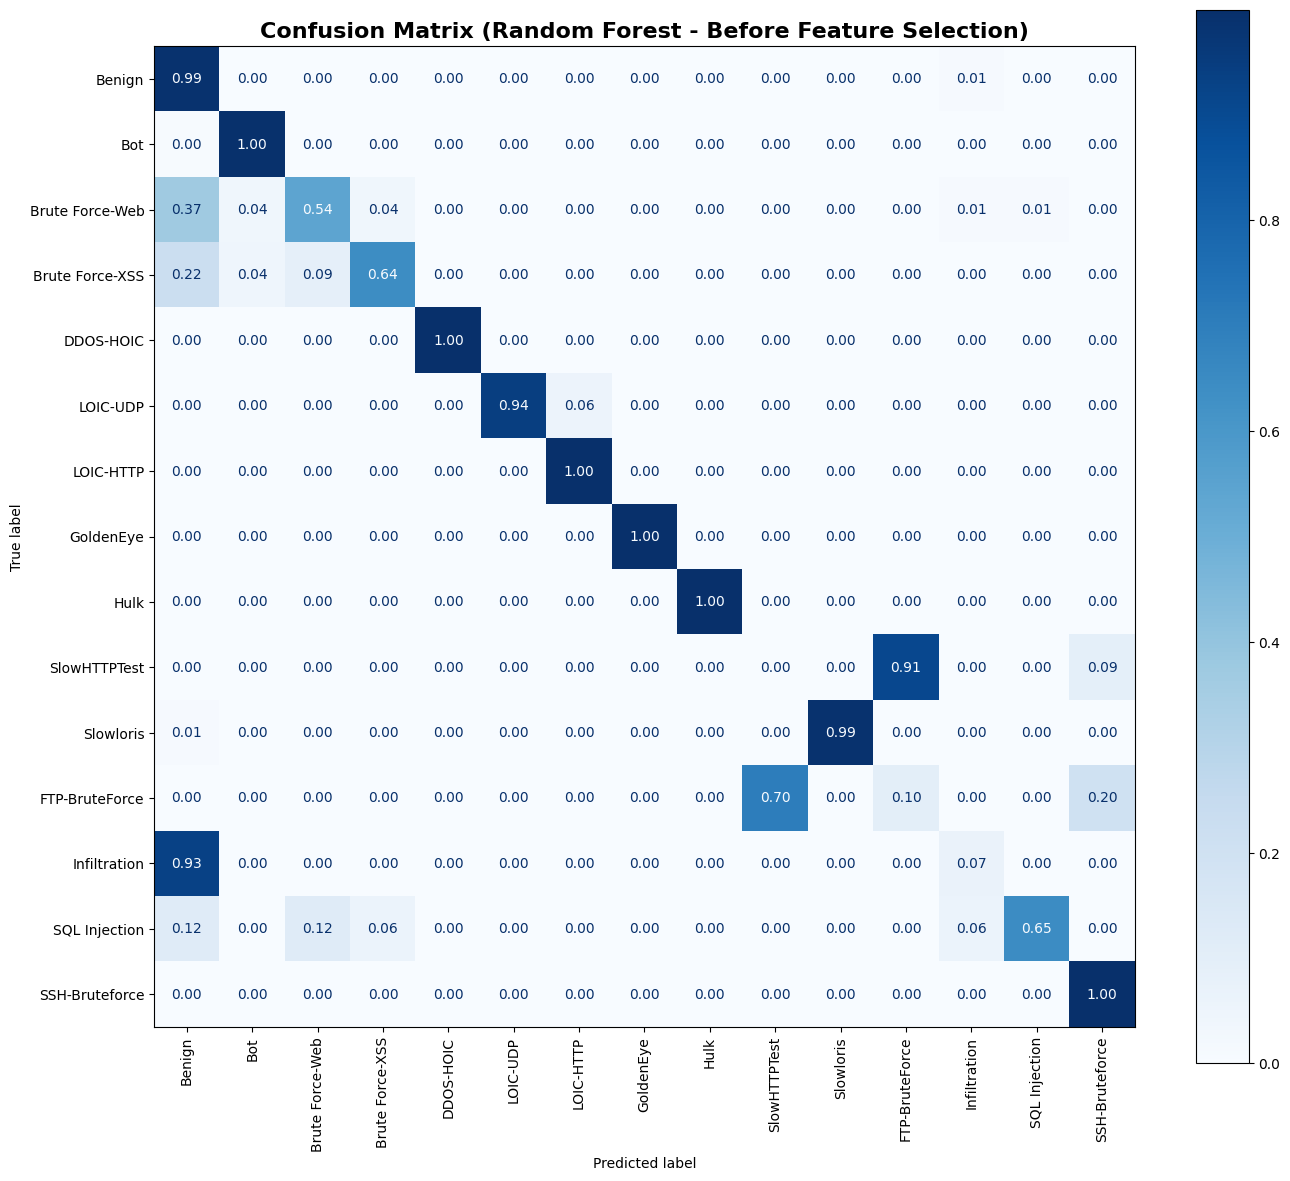

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",     
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix (Random Forest - Before Feature Selection)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()


plt.show()

In [12]:
import os

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

In [13]:
import joblib

joblib.dump(
    rf,
    "outputs/models/random_forest.pkl"
)

print("Random Forest model saved!")

Random Forest model saved!


In [14]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "MCC": [mcc],
    "AUC": [auc]
})

metrics_df.to_csv(
    "outputs/results/rf_metrics.csv",
    index=False
)

print(metrics_df)

           Model  Accuracy  Precision    Recall        F1       MCC       AUC
0  Random Forest  0.974647   0.967166  0.974647  0.970695  0.929508  0.981203


In [15]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

report = classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "outputs/results/rf_classification_report.csv"
)

print("Classification Report Saved!")

Classification Report Saved!


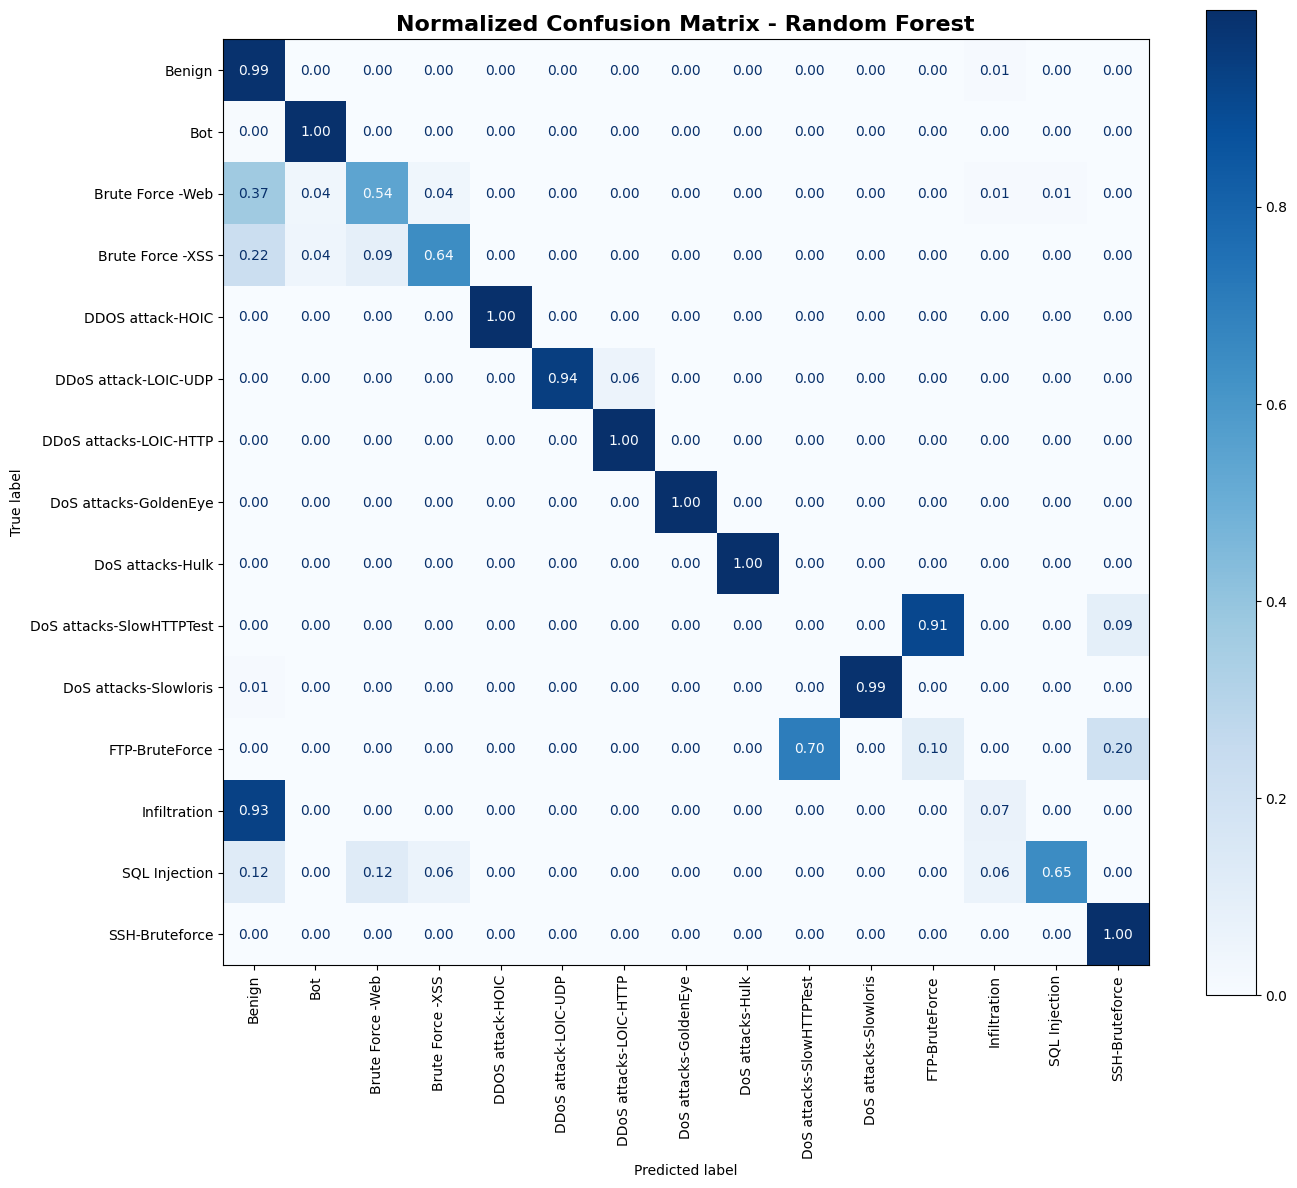

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Normalized Confusion Matrix - Random Forest",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "outputs/results/rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
import os

for root, dirs, files in os.walk("outputs"):
    for file in files:
        print(os.path.join(root, file))

outputs/results/rf_confusion_matrix.png
outputs/results/rf_metrics.csv
outputs/results/rf_classification_report.csv
outputs/models/random_forest.pkl
